# 🧭 Overview

This tutorial walks you through how to read, interpret, and visualize cloudy retrieval results.

We will load the final MCMC chains/Multinest posterior samples, model configurations, cloud data, and opacity data, then prepare them for post-retrieval analysis.

In [20]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mgimg
import matplotlib.colors as colors
import scipy as sp
import numpy as np
import emcee
import os 
from collections import namedtuple
import settings
import utils
import test_module
import retrieval_run
import corner
import pickle as pickle
import TPmod
from specops import proc_spec
from IPython.display import display
%matplotlib inline

## 1. Load the MCMC end chains, arguments and opacities

In [21]:
path = "/Users/kieracharley/Downloads/Retrievals/DBACK1200KEMC504/"

runname = "DBACK1200KEMC504"

# OK finish? 1 for yes, 0 for no.
fin = 1
flatendchain, flatendprobs,ndim = utils.get_endchain(runname,fin,path)
theta_max_end = flatendchain[np.argmax(flatendprobs)]
max_end_like = np.amax(flatendprobs)
samples = flatendchain

argfile =path+runname+"_runargs.pic"
runargs = utils.pickle_load(argfile)
opacityfile =path+runname+"_opacities.pic"
opacities = utils.pickle_load(opacityfile)

cloudfile =path+runname+"_cloudata.pic"
cloudata = utils.pickle_load(cloudfile)

settings.init(runargs)
settings.linelist=opacities[0]
settings.cia=opacities[1]
settings.cloudata=cloudata


with open(path+runname+'_configs.pic', 'rb') as file:
    configs= pickle.load(file)
    
re_params=configs['re_params']
model_config_instance=configs['model_config']

maximum likelihood =  3620.481928988722
maximum likelihood in final 2K iterations=  3620.481928988722


N/50 = 600;
tau: [1771.74253589 1684.99664884 1642.19626944 2097.8956424  1641.25159348
 2339.41147373 1776.36783841 1740.00243959 2046.23865298 1794.05070069
 1969.12826326 1712.57795193 2173.91908974 2131.3791853  2190.74243962
 1750.250319   2147.44457832 1849.69024471 1929.50912459 2149.18413606
 2001.91242776]


Mean autocorrelation time: 1930.471 steps


## 2. check the maximum-likelihood parameter vector and BIC

In [22]:
# import matplotlib.pyplot as plt
# import numpy as np

# # assuming you already have:
# # flatendchain, flatendprobs, ndim, all_params

# n_params = len(all_params)
# fig, axes = plt.subplots(n_params, 1, figsize=(10, 2*n_params), sharex=True)

# for i in range(n_params):
#     ax = axes[i]
#     ax.plot(flatendchain[5000:, i], lw=0.3, alpha=0.7)
#     ax.set_ylabel(all_params[i])
#     if i == 0:
#         ax.set_title("MCMC Chain Traces for Each Parameter")

# axes[-1].set_xlabel("Iteration")
# plt.tight_layout()
# plt.show()


In [23]:
args_instance=settings.runargs
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary)

params_master = namedtuple('params',all_params)
params_instance = params_master(*theta_max_end)
params_instance

params(mh=np.float64(-0.038140743331888896), co=np.float64(1.2809510214529183), logg=np.float64(5.211983594348828), r2d2=np.float64(1.5934751882866467e-19), dlambda=np.float64(0.00012241658851867658), tolerance_parameter_1=np.float64(-32.55431746642809), Tint=np.float64(755.5600122042066), alpha=np.float64(1.3899088852410362), lndelta=np.float64(2.5002712144040444), T1=np.float64(440.6953232662503), T2=np.float64(1264.8001556764368), T3=np.float64(853.9941008898244), logp_mcd_Fe=np.float64(0.1717046911609554), dp_mcd_Fe=np.float64(1.06103552043798), hansen_a_mcd_Fe=np.float64(2.9911596388910913), hansen_b_mcd_Fe=np.float64(0.9655755639193825), tau_mcs_MgSiO3=np.float64(1.2809196382060994), logp_mcs_MgSiO3=np.float64(-0.3402390429070843), dp_mcs_MgSiO3=np.float64(2.2954292174822055), hansen_a_mcs_MgSiO3=np.float64(-0.3771334297615743), hansen_b_mcs_MgSiO3=np.float64(0.5903374718719694))

In [24]:
BIC = (-2.* max_end_like) + (ndim*np.log(runargs.obspec.shape[1]))
print("BIC = "+str(BIC))

BIC = -7143.839428898474


In [25]:
re_params.dictionary['pt']['params'].keys()

dict_keys(['Tint', 'alpha', 'lndelta', 'T1', 'T2', 'T3'])

## 3. Extract the P–T Profile from the MCMC samples.
compute the median and credible intervals (1σ and 2σ) for the atmospheric temperature structure.

In [26]:
all_params,all_params_values =utils.get_all_parametres(re_params.dictionary) 
params_master = namedtuple('params',all_params)
params_instance = params_master(*theta_max_end)

intemp_keys = list(re_params.dictionary['pt']['params'].keys())

if runargs.proftype==1 or runargs.proftype==77:
    p_index_first=params_instance._fields.index(intemp_keys[1]) 
else:
    p_index_first=params_instance._fields.index(intemp_keys[0]) 
    
p_index_last=params_instance._fields.index(intemp_keys[-1])+1

Tsamples = samples[:,p_index_first:p_index_last]
nsamps = Tsamples.shape[0]
Tprofs = np.empty([64,Tsamples.shape[0]])
for i in range(0,nsamps):
    Tprofs[:,i] = TPmod.set_prof(runargs.proftype,runargs.coarsePress,runargs.press,Tsamples[i,:])
    
Tlays = np.empty([64,5])
for i in range(0,64):
    junk = Tprofs[i,:]
    junk2 = np.percentile(junk, [2.4,16, 50, 84,97.6],axis=0)
    junk3 = np.array(junk2)
    Tlays[i,:] = junk3[:]

In [27]:
# Extract maximum likelihood 

bestT = TPmod.set_prof(runargs.proftype,runargs.coarsePress,runargs.press,theta_max_end[p_index_first:p_index_last])

In [28]:
# Update with your exact cloud(s) species, eg. Na2S, KCl, SiO2, etc.

#cloudlist_slab_Mg2SiO4=list(re_params.dictionary["cloud"]["patch 1"]['Mie scattering cloud slab--Mg2SiO4.mieff']['params'])
cloudlist_slab_MgSiO3=list(re_params.dictionary["cloud"]["patch 1"]['Mie scattering cloud slab--MgSiO3.mieff']['params'])
cloudlist_deck=list(re_params.dictionary["cloud"]["patch 1"]['Mie scattering cloud deck--Fe.mieff']['params'])
#cloudlist_slab_Mg2SiO4,cloudlist_slab_MgSiO3,cloudlist_deck
cloudlist_slab_MgSiO3,cloudlist_deck

(['tau_mcs_MgSiO3',
  'logp_mcs_MgSiO3',
  'dp_mcs_MgSiO3',
  'hansen_a_mcs_MgSiO3',
  'hansen_b_mcs_MgSiO3'],
 ['logp_mcd_Fe', 'dp_mcd_Fe', 'hansen_a_mcd_Fe', 'hansen_b_mcd_Fe'])

In [29]:
# uncomment if deck cloud is in your retrieval

cloudsamples_deck = samples[:,params_instance._fields.index(cloudlist_deck[0]):params_instance._fields.index(cloudlist_deck[-1])+1]
cloud_Top_deck  = np.percentile(cloudsamples_deck [:, 0], [16, 50, 84])
cloud_height_deck  = np.percentile(cloudsamples_deck [:, 1], [16, 50, 84])

In [30]:
# get the slab cloud
#cloudtemp_slab_Mg2SiO4 = samples[:,params_instance._fields.index(cloudlist_slab_Mg2SiO4[0]):params_instance._fields.index(cloudlist_slab_Mg2SiO4[-1])+1]
#cloudsamples_slab_Mg2SiO4 = np.empty_like(cloudtemp_slab_Mg2SiO4)
#cloudsamples_slab_Mg2SiO4[:,0] = cloudtemp_slab_Mg2SiO4[:,0]
#cloudsamples_slab_Mg2SiO4[:,1] = cloudtemp_slab_Mg2SiO4[:,1]  #+ cloudtemp_slab[:,2]
#cloudsamples_slab_Mg2SiO4[:,2] = cloudtemp_slab_Mg2SiO4[:,2]
#cloudsamples_slab_Mg2SiO4[:,3] = cloudtemp_slab_Mg2SiO4[:,3]
#cloudsamples_slab_Mg2SiO4[:,4] = cloudtemp_slab_Mg2SiO4[:,4]


# get the slab cloud
cloudtemp_slab_MgSiO3 = samples[:,params_instance._fields.index(cloudlist_slab_MgSiO3[0]):params_instance._fields.index(cloudlist_slab_MgSiO3[-1])+1]
cloudsamples_slab_MgSiO3 = np.empty_like(cloudtemp_slab_MgSiO3)
cloudsamples_slab_MgSiO3[:,0] = cloudtemp_slab_MgSiO3[:,0]
cloudsamples_slab_MgSiO3[:,1] = cloudtemp_slab_MgSiO3[:,1]  #+ cloudtemp_slab[:,2]
cloudsamples_slab_MgSiO3[:,2] = cloudtemp_slab_MgSiO3[:,2]
cloudsamples_slab_MgSiO3[:,3] = cloudtemp_slab_MgSiO3[:,3]
cloudsamples_slab_MgSiO3[:,4] = cloudtemp_slab_MgSiO3[:,4]



#cloud_Base_slab_Mg2SiO4 = np.percentile(cloudsamples_slab_Mg2SiO4[:, 1], [16, 50, 84])
#cloud_height_slab_Mg2SiO4 = np.percentile(cloudsamples_slab_Mg2SiO4[:, 2], [16, 50, 84])
#cloud_Tau_slab_Mg2SiO4 = np.percentile(cloudsamples_slab_Mg2SiO4[:, 0], [16, 50, 84])



cloud_Base_slab_MgSiO3 = np.percentile(cloudsamples_slab_MgSiO3[:, 1], [16, 50, 84])
cloud_height_slab_MgSiO3 = np.percentile(cloudsamples_slab_MgSiO3[:, 2], [16, 50, 84])
cloud_Tau_slab_MgSiO3 = np.percentile(cloudsamples_slab_MgSiO3[:, 0], [16, 50, 84])


/var/folders/t5/q9r7xflx2_g_8431268s2g_r0000gn/T/ipykernel_19620/3299960083.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


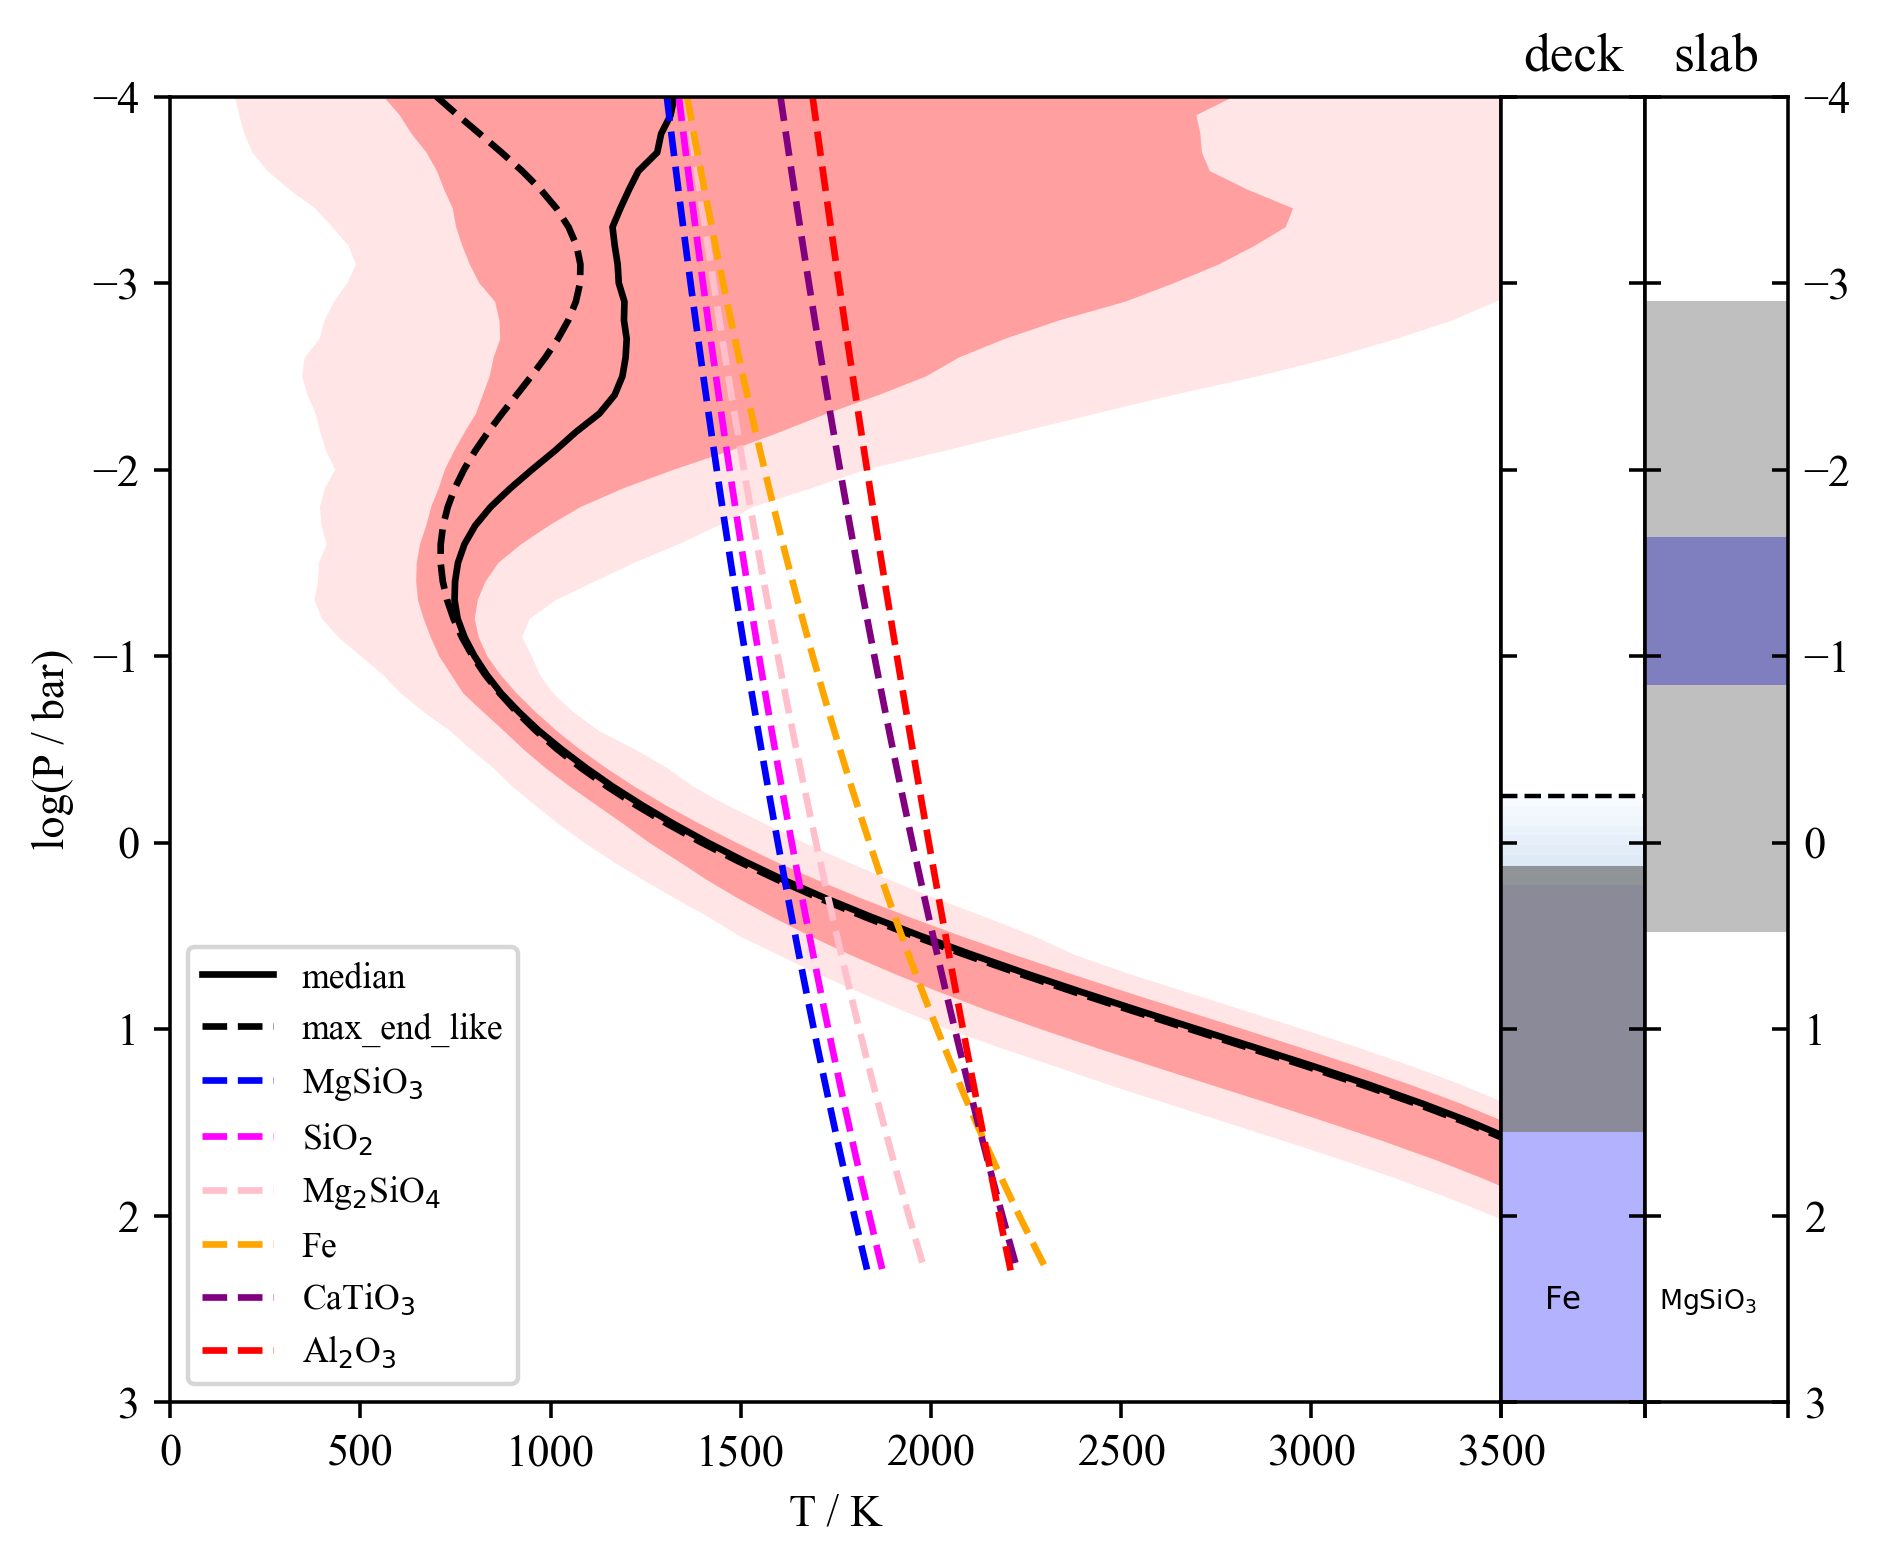

In [31]:
# Plotting the thermal profile, max likelihood, and cloud(s) location
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=320)

prf = fig.add_axes([0.1, 0.1, 0.65, 0.85])

prf.axis([0., 3500.,3.0,-4.0])
plt.ylabel(r'log(P / bar)')
plt.xlabel('T / K')


# Plotting deck cloud (Fe)

logP = np.log10(runargs.press)
cld1 = fig.add_axes([0.75,0.1,0.07,0.85],xticklabels=[],xlim=[0,1])
cld1.axis([0,1,3,-4])
cld1.tick_params(axis='y',direction='in',left=True,right=True,labelleft=False,labelright=False)

BesTprof = TPmod.set_prof(runargs.proftype,runargs.coarsePress,runargs.press,params_instance[p_index_first:p_index_last])


npts = 10

cmap = mpl.cm.Blues
y = np.linspace(cloud_Top_deck[1] - cloud_height_deck[1],cloud_Top_deck[1],npts)
normalize = mpl.colors.Normalize(vmin=y.min(), vmax=y.max()+2)
for j in range(0,npts-1):
         cld1.fill_between([0.,1.],y[j],y[j+1],facecolor=cmap(normalize(y[j])), linewidth=0.0)

cld1.fill_between([0.,1.],3.0,cloud_Top_deck[1],facecolor='blue',alpha=0.3)
cld1.fill_between([0,1.],cloud_Top_deck[2],cloud_Top_deck[0],facecolor='grey',alpha=0.8)
cld1.plot([0,1],[cloud_Top_deck[1] -cloud_height_deck[1],cloud_Top_deck[1] - cloud_height_deck[1]],'k--',linewidth=1.0)
cld1.set_title("deck")
cld1.text(0.3,2.5,r"$\rm Fe$",fontsize=7)


# Plotting slab cloud (Mg2SiO4)

#cld2 = fig.add_axes([0.82,0.1,0.07,0.85],xticklabels=[],xlim=[0,1])
#cld2.axis([0,1,3,-4])
#cld2.tick_params(axis='y',direction='in',left=True,right=True,labelleft=False,labelright=False)

#cld2.fill_between([0,1.],cloud_Base_slab_Mg2SiO4[1],cloud_Base_slab_Mg2SiO4[1] - cloud_height_slab_Mg2SiO4[1],facecolor='blue',alpha=0.5)
#cld2.fill_between([0,1.],cloud_Base_slab_Mg2SiO4[2],cloud_Base_slab_Mg2SiO4[1] - cloud_height_slab_Mg2SiO4[2],facecolor='grey',alpha=0.5)
#cld2.set_title("slab")
#cld2.text(0.10,2.5,r"$\rm Mg_{2}SiO_{4}$",fontsize=6)


# Plotting slab cloud (MgSiO3)

cld3 = fig.add_axes([0.82,0.1,0.07,0.85],xticklabels=[],xlim=[0,1])
cld3.axis([0,1,3,-4])
cld3.tick_params(axis='y',direction='in',left=True,right=True,labelleft=False,labelright=True)

cld3.fill_between([0,1.],cloud_Base_slab_MgSiO3[1],cloud_Base_slab_MgSiO3[1] - cloud_height_slab_MgSiO3[1],facecolor='blue',alpha=0.5)
cld3.fill_between([0,1.],cloud_Base_slab_MgSiO3[2],cloud_Base_slab_MgSiO3[1] - cloud_height_slab_MgSiO3[2],facecolor='grey',alpha=0.5)
cld3.set_title("slab")
cld3.text(0.10,2.5,r"$\rm MgSiO_{3}$",fontsize=6)




d1, = prf.plot(Tlays[:,2],logP,'k-',label='median')
prf.fill_betweenx(logP,Tlays[:,1], Tlays[:,3], facecolor='red', alpha=0.3)
prf.fill_betweenx(logP,Tlays[:,0], Tlays[:,4], facecolor='red', alpha=0.1)

d2, = prf.plot(BesTprof,logP,'k--',label='max_end_like')



pero = 10.0**4 / (5.125 - 0.277*logP - 0.554*0.0)

qtz = 10.0**4 / (6.12 - 0.34*logP - 0.69*0.0)
qtz_alt = 10.0**4 / (6.27 - 0.34*logP - 0.69*0.0)


enst = 10.0**4/(6.26 - 0.35*logP-0.70*0.0)
fost = 10.0**4/(5.89 - 0.37*logP-0.73*0.0)
iron = 10.0**4/(5.44 - 0.48*logP-0.48*0.0)
cr =  10.0**4/(6.528 - 0.491*logP-0.491*0.0)
al2o3 = 10.0**4 / (5.0139 - 0.21794*(logP) + 2.2636E-03*(logP)**2.0 - 0.580*0.0)

c1, = prf.plot(enst,logP,'--',color='blue',linewidth=1.5, label='MgSiO$_3$')
c2, = prf.plot(qtz,logP,'--',color='magenta',linewidth=1.5, label='SiO$_2$')
c3, = prf.plot(fost,logP,'--',color='pink',linewidth=1.5,label='Mg$_2$SiO$_4$')
c4, = prf.plot(iron,logP,'--',color='orange',linewidth=1.5, label='Fe')
c5, = prf.plot(pero,logP,'--',color='purple',linewidth=1.5, label='CaTiO$_3$')
c6, = prf.plot(al2o3,logP,'--',color='red',linewidth=1.5, label='Al$_2$O$_3$')

prf.legend(handles=[d1,d2,c1,c2,c3,c4,c5,c6],prop={'size':8}) 


plt.tight_layout()
plt.show()

## 4. Check the Mass and Radius from the retrieved parameters r2d2 and logg.

In [32]:
D = 3.086e+16 * model_config_instance.dist

r2d2_index=params_instance._fields.index('r2d2')
r2d2 =theta_max_end[r2d2_index]


logg_index=params_instance._fields.index('logg')
logg =theta_max_end[logg_index]


if (r2d2 > 0.):
    R = np.sqrt(r2d2) * D
g = (10.**logg)/100.
M = (R**2 * g/(6.67E-11))/1.898E27
Rj = R / 69911.e3
print(M,Rj)

70.307426595373 1.0572417639040028


In [33]:
r2d2 = samples[:,r2d2_index,]
logg = samples[:,logg_index]


R = np.sqrt(r2d2) * D
g = (10.**logg)/100.
M = (R**2 * g/(6.67E-11))/1.898E27
Rj = R / 69911.e3
Msig = np.percentile(M,[16,50,84])
Rsig =  np.percentile(Rj,[16,50,84])
print('M = ',Msig[1], '+ ', Msig[2] - Msig[1], ' - ', Msig[1] - Msig[0])
print('R = ',Rsig[1], '+ ', Rsig[2] - Rsig[1], ' - ', Rsig[1] - Rsig[0])

M =  55.788806330226 +  18.3111434438651  -  34.67371685980643
R =  1.0069627357535411 +  0.03563281924936179  -  0.2304284018574686


## 5. Corner Plot
Visualize the posterior distributions of all retrieved parameters using a corner plot.

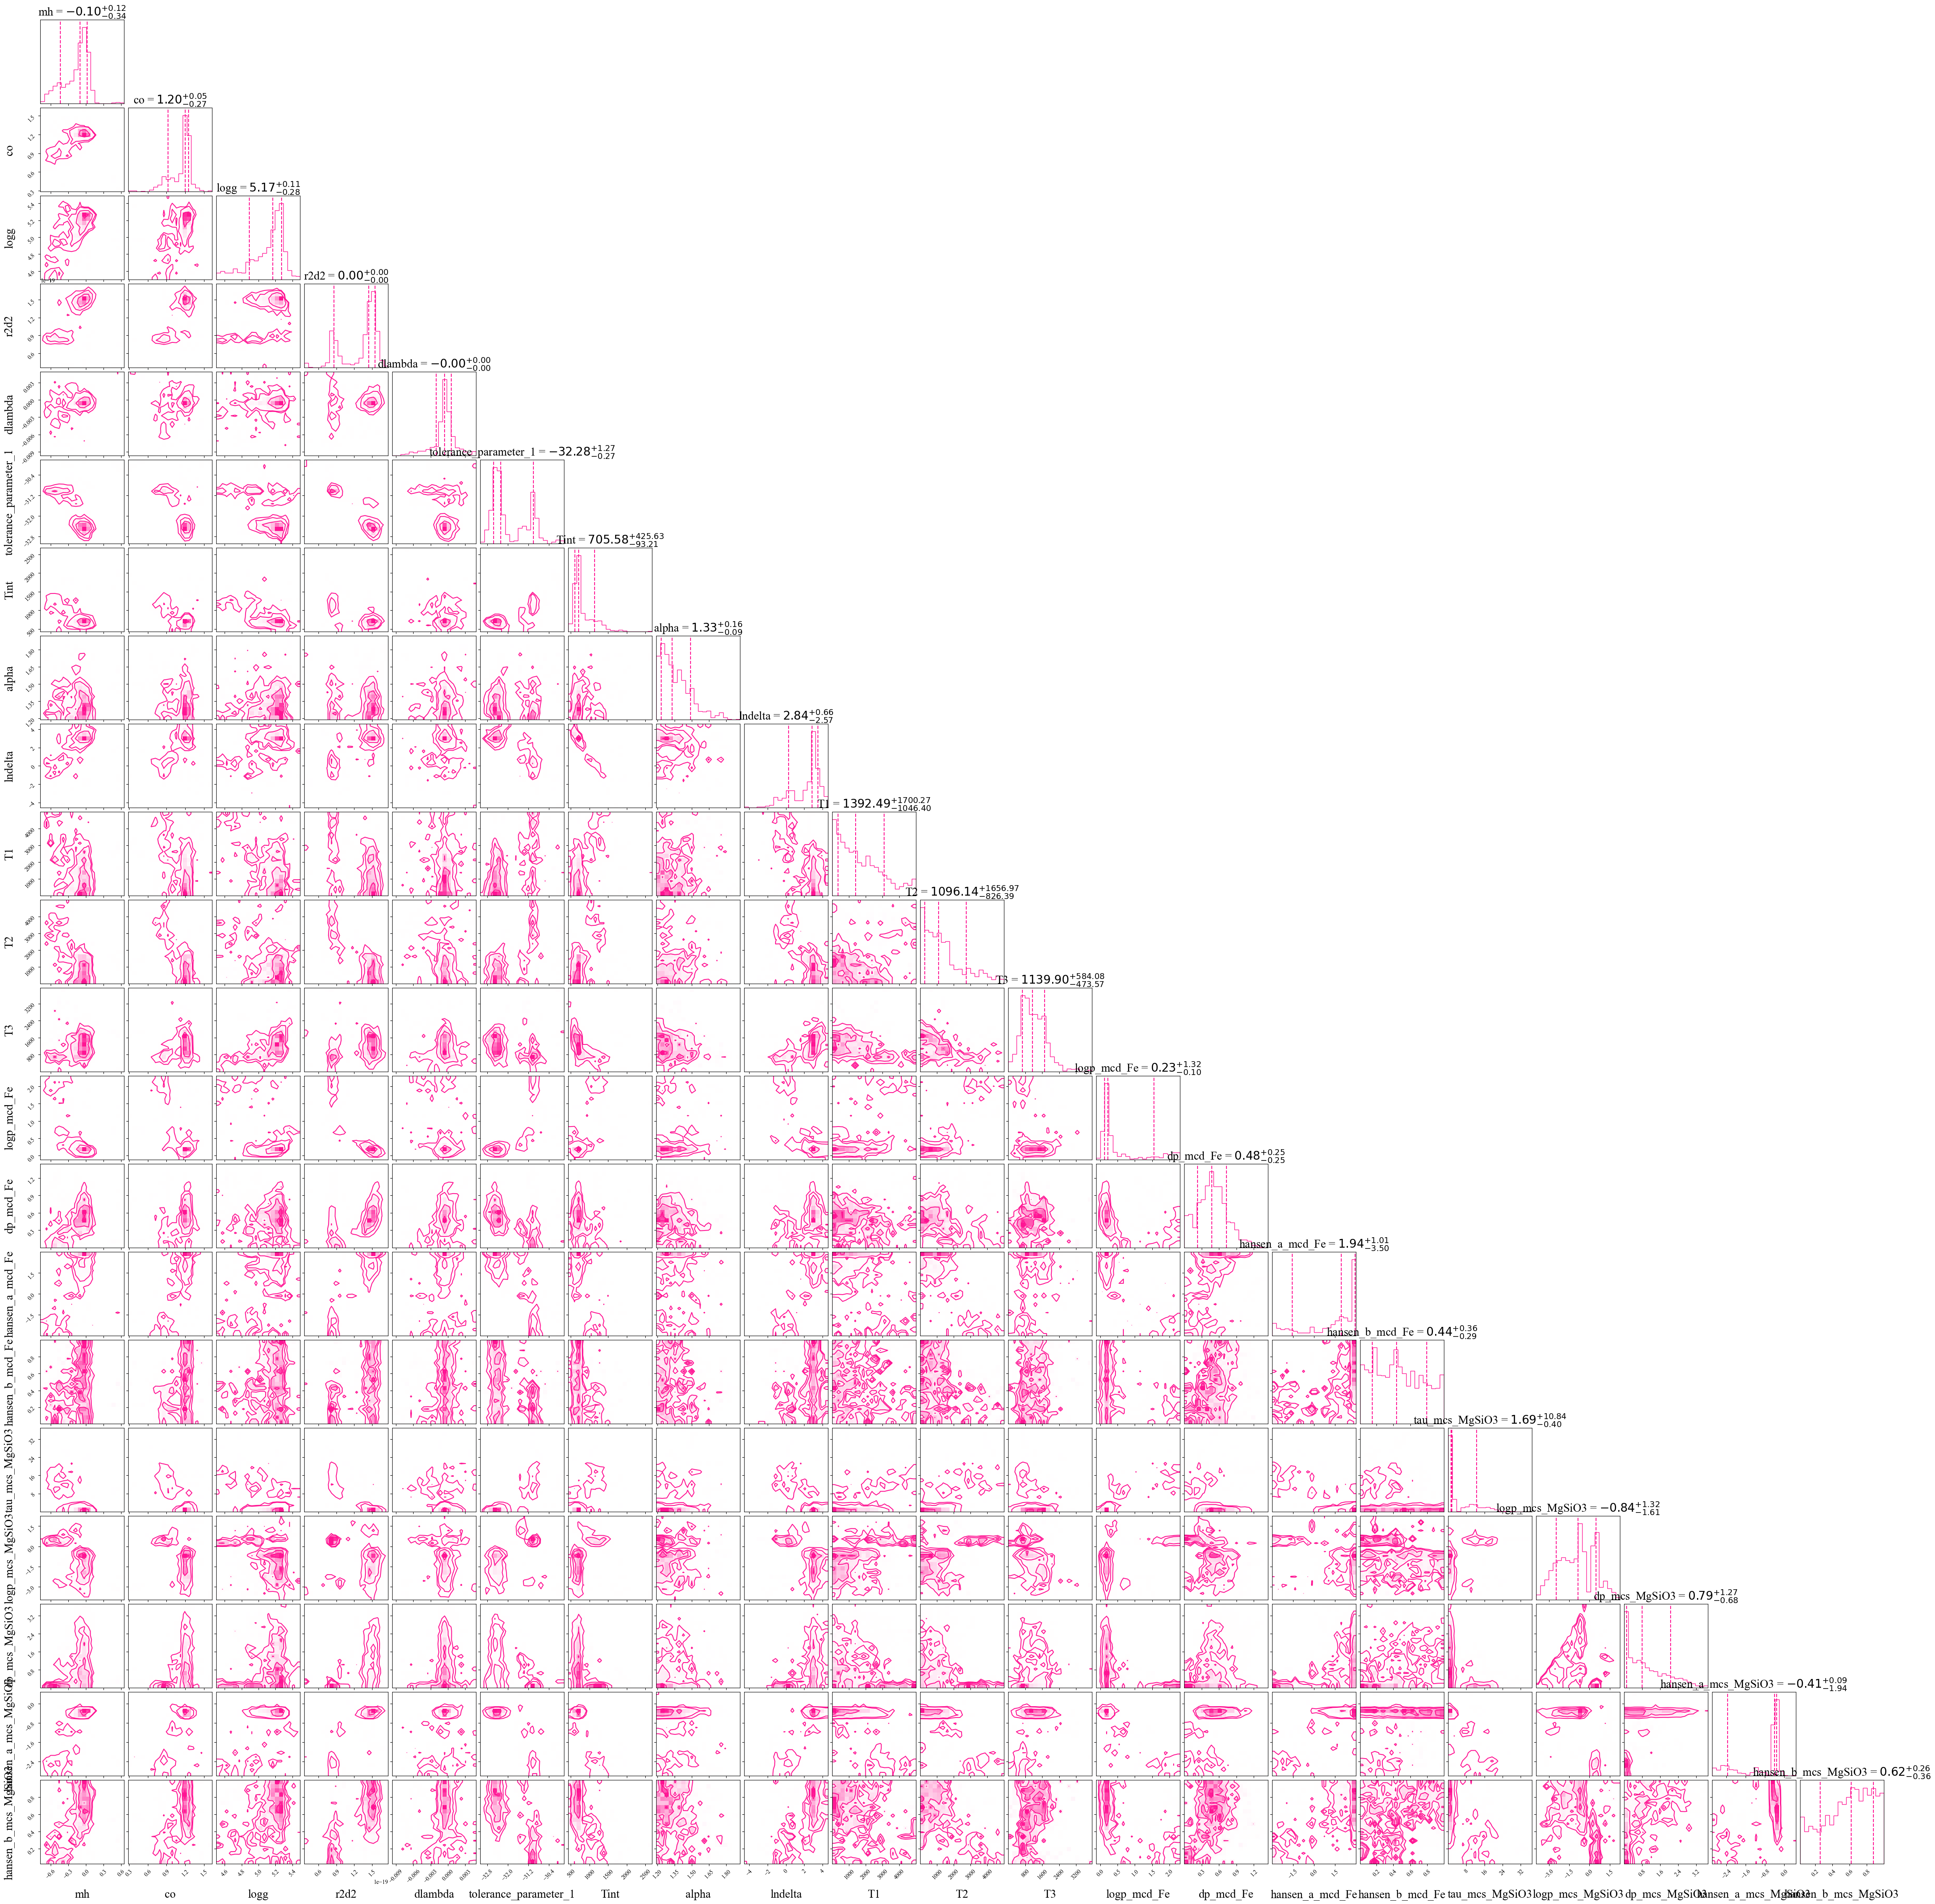

In [34]:
fig = corner.corner(samples,scale_hist=False,plot_datapoints =False,\
                    labels=all_params,\
                    quantiles=[0.16, 0.5, 0.84],show_titles=True, title_kwargs={"fontsize": 20},\
                    label_kwargs={"fontsize": 20},color='deeppink')
#plt.savefig('DBACK1200KEMC504_cornerplot.png', dpi ='figure', format = 'png')

## 6. Plot the Fitted Spectrum
generate the best-fit model spectrum and compute credible intervals from the posterior samples to compare with the observed data.

In [ ]:
# get diagnostics along with the spectrum
gnostics = 0
# Now run the model again to get your model spectrum and process to make it look like the data

# leave commented for a cloudy retrieval
#settings.cloudata = np.asfortranarray(np.zeros([4,102]))
trimspec, photspec, tauspec,cfunc = test_module.modelspec(theta_max_end,re_params,runargs,gnostics)
wave,topspec=proc_spec(inputspec=trimspec, theta=params_instance, re_params=re_params, args_instance=args_instance, do_scales=args_instance.do_scales, do_shift=args_instance.do_shift)


In [ ]:
# Now grab 100 random draws from the posterior
pltspec = np.zeros((100,runargs.obspec[0,:].size))
samp= np.empty(ndim)
samples = flatendchain
sid = np.zeros(100)
for i in range (0,100):
    sid[i]= np.random.randint(0,high = len(samples))
    samp = samples[int(sid[i]),:]
    
    trimspec, photspec, tauspec,cfunc = test_module.modelspec(samp,re_params,runargs,gnostics)
    pltspec[i,:] = proc_spec(inputspec=trimspec, theta=params_instance, re_params=re_params, args_instance=args_instance, do_scales=args_instance.do_scales, do_shift=args_instance.do_shift)[1]

# get the intervals for the distribution of model spectra
specdist = np.empty([runargs.obspec[0].size,5])
for i in range(0,runargs.obspec[0].size):
    junk = pltspec[:,i]
    junk2 = np.percentile(junk, [2.4,16, 50, 84,97.6],axis=0)
    junk3 = np.array(junk2)
    specdist[i,:] = junk3[:]


In [ ]:
# plot the spectra
plt.rc('font',family='Times New Roman')
fig=plt.figure(dpi=120)


d1, = plt.plot(runargs.obspec[0,:],runargs.obspec[1,:],'k-',label = "data")
plt.fill_between(runargs.obspec[0], runargs.obspec[1,:] - runargs.obspec[2,:],runargs.obspec[1,:] + runargs.obspec[2,:],facecolor='grey',alpha=0.5)

#t1, = plt.plot(runargs.obspec[0,:],topspec,'g-',linewidth=1, label = runname+" max likelihood")
t1, = plt.plot(runargs.obspec[0,:],topspec,c='deeppink',linewidth=1, label = runname+" max likelihood")


#r1, = plt.plot(runargs.obspec[0],specdist[:,2],'y-',linewidth=0.5, label = "median")
r1, = plt.plot(runargs.obspec[0],specdist[:,2],c='lightpink',linewidth=0.5, label = "median")
#plt.fill_between(obspec[0],specdist[:,0],specdist[:,4],facecolor='red',alpha=0.2)
plt.fill_between(runargs.obspec[0],specdist[:,1],specdist[:,3],facecolor='indigo',alpha=0.5)
#plt.fill_between(obspec[0,:],obspec[1,:]-obspec[2,:],obspec[1,:]+obspec[2,:],facecolor='red',alpha=0.2)


plt.legend(handles=[d1,t1,r1])


plt.ylabel(r'$ F_{\lambda}$ / $Wm^{-2} \mu m^{-1}$')
plt.xlabel('Wavelength / $\mu m$')
#plt.savefig(runname+"_SPAG_SPEC.png",format='png', dpi=320)

In [ ]:
# Walker trace plots

with open(path + runname + '_snapshot.pic', 'rb') as f:
    pos, lnprob = pickle.load(f)

nwalkers, nsteps, ndim = pos.shape
print(f"Chain shape: {pos.shape} (walkers, steps, parameters)")

param_index = 2 
plt.figure(figsize=(10, 6))
for w in range(nwalkers):
    plt.plot(pos[w, :, param_index], alpha=0.3, lw=0.5)
plt.xlabel("Step")
plt.ylabel(all_params[param_index])
plt.title(f"Trace plot for {all_params[param_index]}")
plt.tight_layout()
plt.show()